In [ ]:
import pandas as pd 
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Model, Sequential


In [ ]:
from numpy import ndarray
from matplotlib.pyplot import subplots, show
from keras.datasets.cifar10 import load_data as load_cifar10
# model building imports
from keras import Model, Sequential, Input

from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from keras.layers import LeakyReLU
from keras.ops import add
from keras.utils import to_categorical
# model training imports
from keras.optimizers import SGD
from keras.losses import CategoricalCrossentropy
from keras.metrics import CategoricalAccuracy, AUC, F1Score
from keras.callbacks import ModelCheckpoint, CSVLogger, LearningRateScheduler

In [1]:
import os

dataset_path = "../data"

for artist in os.listdir(dataset_path):
    artist_path = os.path.join(dataset_path, artist)

    if os.path.isdir(artist_path):
        for img in os.listdir(artist_path):
            print(os.path.join(artist_path, img))

../data/wikiart/Gustave_Dore
../data/wikiart/Edgar_Degas
../data/wikiart/Eugene_Boudin
../data/wikiart/Raphael_Kirchner
../data/wikiart/Pierre_Auguste_Renoir
../data/wikiart/.DS_Store
../data/wikiart/John_Singer_Sargent
../data/wikiart/Ivan_Shishkin
../data/wikiart/Claude_Monet
../data/wikiart/Marc_Chagall
../data/wikiart/Boris_Kustodiev
../data/wikiart/Ivan_Aivazovsky
../data/wikiart/Pyotr_Konchalovsky
../data/wikiart/Childe_Hassam
../data/wikiart/Paul_Cezanne
../data/wikiart/Camille_Pissarro
../data/wikiart/Salvador_Dali
../data/wikiart/Ilya_Repin
../data/wikiart/Vincent_van_Gogh
../data/wikiart/Pablo_Picasso
../data/wikiart/Albrecht_Durer
../data/wikiart/Nicholas_Roerich
../data/wikiart/Rembrandt
../data/wikiart/Martiros_Saryan


In [5]:
import os

dataset_path = "../data/wikiart"

for artist in os.listdir(dataset_path):
    artist_path = os.path.join(dataset_path, artist)
    if artist.startswith("."):
        continue
    if os.path.isdir(artist_path):
        for image_file in os.listdir(artist_path):
            image_path = os.path.join(artist_path, image_file)
            print(image_path)

../data/wikiart/Gustave_Dore/gustave-dore_pantagruel.jpg
../data/wikiart/Gustave_Dore/gustave-dore_devils-and-barrators(1).jpg
../data/wikiart/Gustave_Dore/gustave-dore_the-eunoe.jpg
../data/wikiart/Gustave_Dore/gustave-dore_the-descent-of-the-spirit.jpg
../data/wikiart/Gustave_Dore/gustave-dore_don-quixote-83.jpg
../data/wikiart/Gustave_Dore/gustave-dore_don-quixote-97.jpg
../data/wikiart/Gustave_Dore/gustave-dore_the-inferno-canto-6-1.jpg
../data/wikiart/Gustave_Dore/gustave-dore_don-quixote-68.jpg
../data/wikiart/Gustave_Dore/gustave-dore_don-quixote-40.jpg
../data/wikiart/Gustave_Dore/gustave-dore_don-quixote-140.jpg
../data/wikiart/Gustave_Dore/gustave-dore_don-quixote-54.jpg
../data/wikiart/Gustave_Dore/gustave-dore_crucified-man.jpg
../data/wikiart/Gustave_Dore/gustave-dore_the-inferno-canto-13.jpg
../data/wikiart/Gustave_Dore/gustave-dore_the-resurrection.jpg
../data/wikiart/Gustave_Dore/gustave-dore_they-plunged-their-swords-through-his-body.jpg
../data/wikiart/Gustave_Dore/gu

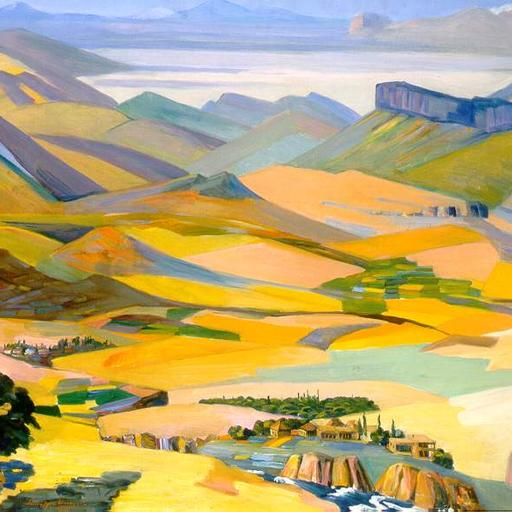

In [6]:
from PIL import Image

img = Image.open("../data/wikiart/Martiros_Saryan/martiros-saryan_armenia-1959.jpg")
img

In [7]:
dataset_path = "../data/wikiart"

In [8]:
import tensorflow as tf

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(128, 128),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(128, 128),
    batch_size=32
)

Found 13340 files belonging to 23 classes.
Using 10672 files for training.
Found 13340 files belonging to 23 classes.
Using 2668 files for validation.


In [9]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

In [11]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation="relu", input_shape=(128,128,3)),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(23, activation="softmax")
])

In [12]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [13]:
model.fit(train_ds, validation_data=val_ds, epochs=20)

Epoch 1/20
334/334 ━━━━━━━━━━━━━━━━━━━━ 52s 154ms/step - accuracy: 0.2024 - loss: 2.7795 - val_accuracy: 0.2867 - val_loss: 2.4806
Epoch 2/20
334/334 ━━━━━━━━━━━━━━━━━━━━ 52s 155ms/step - accuracy: 0.3449 - loss: 2.2280 - val_accuracy: 0.3684 - val_loss: 2.2074
Epoch 3/20
334/334 ━━━━━━━━━━━━━━━━━━━━ 54s 160ms/step - accuracy: 0.4764 - loss: 1.7547 - val_accuracy: 0.3744 - val_loss: 2.2269
Epoch 4/20
334/334 ━━━━━━━━━━━━━━━━━━━━ 55s 164ms/step - accuracy: 0.6548 - loss: 1.1638 - val_accuracy: 0.3392 - val_loss: 2.6564
Epoch 5/20
334/334 ━━━━━━━━━━━━━━━━━━━━ 54s 163ms/step - accuracy: 0.8162 - loss: 0.6378 - val_accuracy: 0.3407 - val_loss: 3.1608
Epoch 6/20
334/334 ━━━━━━━━━━━━━━━━━━━━ 56s 168ms/step - accuracy: 0.9142 - loss: 0.3155 - val_accuracy: 0.3564 - val_loss: 3.7318
Epoch 7/20
334/334 ━━━━━━━━━━━━━━━━━━━━ 63s 187ms/step - accuracy: 0.9551 - loss: 0.1759 - val_accuracy: 0.3624 - val_loss: 4.0773
Epoch 8/20
334/334 ━━━━━━━━━━━━━━━━━━━━ 57s 171ms/step - accuracy: 0.9692 - loss: 0